In [ ]:
from langchain_community.document_loaders import TextLoader,WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from pydantic import BaseModel,Field
from typing import Literal,List,TypedDict,Annotated
from dataclasses import dataclass
from langgraph.graph import StateGraph,START,END
from IPython.display import display,Image
from langchain_core.prompts import PromptTemplate,ChatPromptTemplate


import warnings
warnings.filterwarnings("ignore")
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm=ChatGroq(model="llama-3.1-8b-instant",temperature=0.1)


In [80]:
class Worker(BaseModel):
     satisfaction:Literal["satisfy","notsatisfy"]=Field(description="Return 'satisfy' if answer is correct, else 'notsatisfy'")

llm_with_structured_output=llm.with_structured_output(Worker)
    

class State(TypedDict):
    query:str
    sub_questions:List[str]
    content:str
    answer:str
    evaluation:str

from langchain_community.document_loaders import PyMuPDFLoader
document=PyMuPDFLoader("GEN AI Book.pdf").load()
splitter=RecursiveCharacterTextSplitter(chunk_size=550,chunk_overlap=50)
docs=splitter.split_documents(document)
embeddings=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectordb=FAISS.from_documents(docs,embeddings)
retriever_obj=vectordb.as_retriever(search_type="mmr",search_kwargs={"k":5,"fetch_k":15,"lambda_mult":0.25})

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 747.76it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def planner(state:State):
    prompt=f"Please decompose the user question into three to foutr reasoning sub questions and each question must be start with ### 1. ,### 2. , ### 3. like that question :\n\n {state["query"]}"
    result=llm.invoke(prompt).content
    sub_questions=[question.strip() for question in result.split("\n") if question.startswith("###")]
    sub_questions=[question.replace("###","") for question in sub_questions]

    return {"sub_questions":sub_questions}

def retriever(state:State):
    
    retriever_content=[]
    for question in state["sub_questions"]:
        result=retriever_obj.invoke(question)
        combined=" ".join([doc.page_content for doc in result])
        retriever_content.append(combined)
    total_retriever_content=" ".join(content for content in retriever_content)

    return {"content":total_retriever_content}

def answer_generator(state:State):
    prompt = f"""You are a helpful AI assistant.
STRICT INSTRUCTION:
- ONLY answer the question
- DO NOT evaluate
- DO NOT score
- DO NOT explain quality
- Give a clear and direct answer

Context:
{state['content']}

Question:
{state['query']}

Answer:
"""

    answer=llm.invoke(prompt)
    return {"answer":answer.content}

def controller(state:State):
    prompt=f"""valuate the answer. Question:{state['query']}Answer:{state['answer']}"
    Return:- satisfy or notsatisfy"""
    answer=llm_with_structured_output.invoke(prompt)
    return {"evaluation":answer.satisfaction}
def evaluator(state:State):
    if state["evaluation"]=="satisfy":
        return "end"
    else:
        return "retry"


    


    


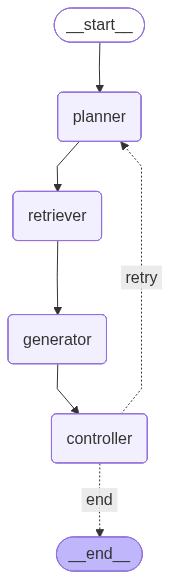

In [88]:
graph = StateGraph(State)

graph.add_node("planner", planner)
graph.add_node("retriever", retriever)
graph.add_node("generator", answer_generator)
graph.add_node("controller", controller)

graph.set_entry_point("planner")

graph.add_edge("planner", "retriever")
graph.add_edge("retriever", "generator")
graph.add_edge("generator", "controller")

graph.add_conditional_edges(
    "controller",
    evaluator,
    {
        "end": END,
        "retry": "planner"
    }
)

app = graph.compile()
app

In [92]:
app.invoke({"query":{"WHat is Gen ai"}})
    

1


{'query': {'WHat is Gen ai'},
 'sub_questions': [" 1. What does 'Gen' stand for in the context of 'Gen AI'?",
  " 2. Is 'Gen AI' referring to a specific type of artificial intelligence, and if so, what are its characteristics?",
  " 3. How does 'Gen AI' differ from other types of artificial intelligence, such as narrow or general AI?",
  " 4. What are the potential applications and implications of 'Gen AI' in various fields, such as technology, healthcare, or education?"],
 'content': 'THE BIG BOOK OF GENERATIVE AI\nADDING MODEL AND PARAMETERS TO YOUR GENAI APPLICATION\nAfter playing with a few prompts and parameters, you can use the same settings and model in your  \nGenAI application.\n104 and GenAI \nMosaic AI: Product page covering the features of Mosaic AI within Databricks\n117 and less than $1,000 in compute cost to develop. We hope you will find the learnings useful, as we believe \nthey apply to a wide class of GenAI use cases. More importantly, it has allowed us to take advan

In [95]:
result=app.invoke({"query":"what are the steps invoked in Gen Ai"})
print(result["answer"])

1
1. Generate evaluation dataset: 
2. Generate answer sheets: 
3. Compare different prompts and parameters: 
4. Train your own image generation model: 
5. Plan a path from basic to advanced GenAI applications: 
6. Use retrieval augmented generation (RAG): 
7. Evaluate LLMs: 
8. Build a custom LLM: 
9. Pretrain your own model: 
10. Integrate image generation into the design process:
